<a href="https://colab.research.google.com/github/nataliamarinn/series_tiempo_scripts/blob/main/PRACTICA_AST_Clase_5_1_Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 5 - Modelos de Ensambles - Xgboost</h3>
    <h3>Ejercicio 1_Sincronico</h3>
        <p>Docentes: Rodrigo Del Rosso, Drago Braian <p>
</div>

**Modelos Ensambles**   

Los modelos de Gradient Boosting, como XGBoost y LightGBM, han demostrado su eficacia en una amplia gama de aplicaciones de aprendizaje automático, desde clasificación hasta regresión. Sin embargo, una de las áreas más desafiantes y emocionantes en las que estos algoritmos han encontrado aplicabilidad es en la predicción de series de tiempo.

¿Qué es el Boosting? Boosting es una técnica conjunta de aprendizaje automático que combina múltiples modelos débiles (weak models) en un único modelo fuerte. En Boosting, cada modelo aprende de los errores del modelo anterior, lo que da como resultado un modelo mejor en general. El objetivo es mejorar la precisión de un modelo reduciendo la varianza y el sesgo en los datos.

Las principales diferencias de LightGBM frente a XGBoost es su estrategia de crecimiento de árboles en forma de hojas, su técnica exclusiva de agrupación de funciones y su menor consumo de memoria.


**Objetivo del Ejercicio**: Elaborar un modelo de predicción del Consumo de energía por hora utilizando un modelo Xgboost.  
Dataset: Más de 10 años de datos de consumo de energía por hora de una organización de transmisión regional (RTO) en los Estados Unidos, en megavatios.  

Queremos predecir el consumo futuro.  

Documentación: https://xgboost.readthedocs.io/en/stable/python/python_intro.html

Fuente del ejercicio: https://www.youtube.com/watch?v=z3ZnOW-S550&t=59s

Fuente de los datos: https://www.pjm.com/

Carga de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import plot_importance, plot_tree
color_pal = sns.color_palette()
plt.style.use('tableau-colorblind10')

# Carga y Procesamiento inicial del dataset

In [ ]:
URL= 'https://raw.githubusercontent.com/braiandrago/AST/main/consumo_2.csv'
df = pd.read_csv(URL)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
df['Datetime'].dtype #otra forma de verificar

dtype('O')

In [ ]:
df.head(10)

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0
5,2002-01-01 06:00:00,28654.0
6,2002-01-01 07:00:00,29308.0
7,2002-01-01 08:00:00,29595.0
8,2002-01-01 09:00:00,29943.0
9,2002-01-01 10:00:00,30692.0


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'],format = '%Y-%m-%d %H:%M:%S')

In [ ]:
df = df.set_index('Datetime')
df.sort_index(inplace=True)
print(df.shape)
df.head()

(145366, 1)


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [ ]:
df.tail(5)

,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


Los datos tienen una frecuencia de registro cada 1 hora

**Visualizamos la serie:**

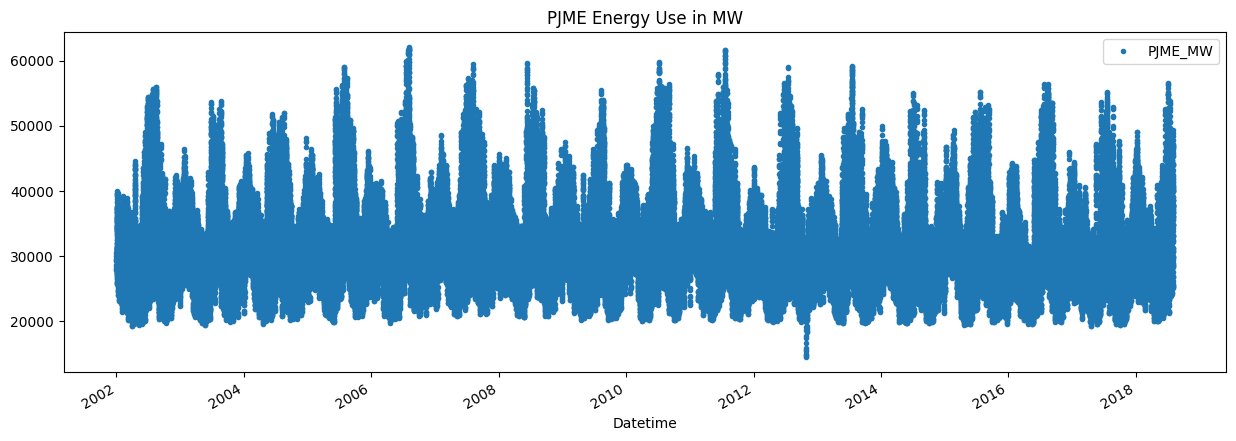

In [ ]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

Que observamos en la gráfica?

**Valores faltantes:**

In [ ]:
print('Cantidad de NaNs:')
for column in df:
    nans = df[column].isna().sum()
    print(f'\tColumna {column}: {nans}')

Cantidad de NaNs:
	Columna PJME_MW: 0


In [ ]:
df.tail()

,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


**Análisis de Outliers**

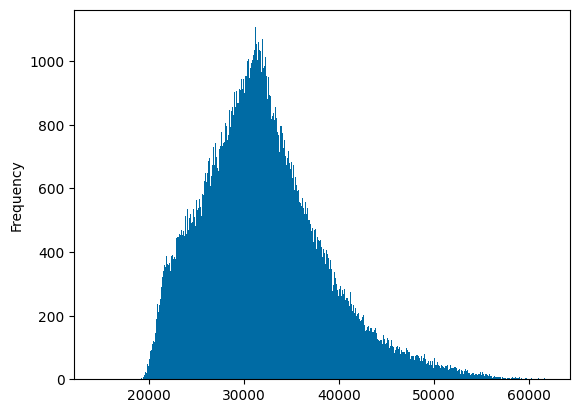

In [ ]:
df['PJME_MW'].plot(kind='hist', bins=500);

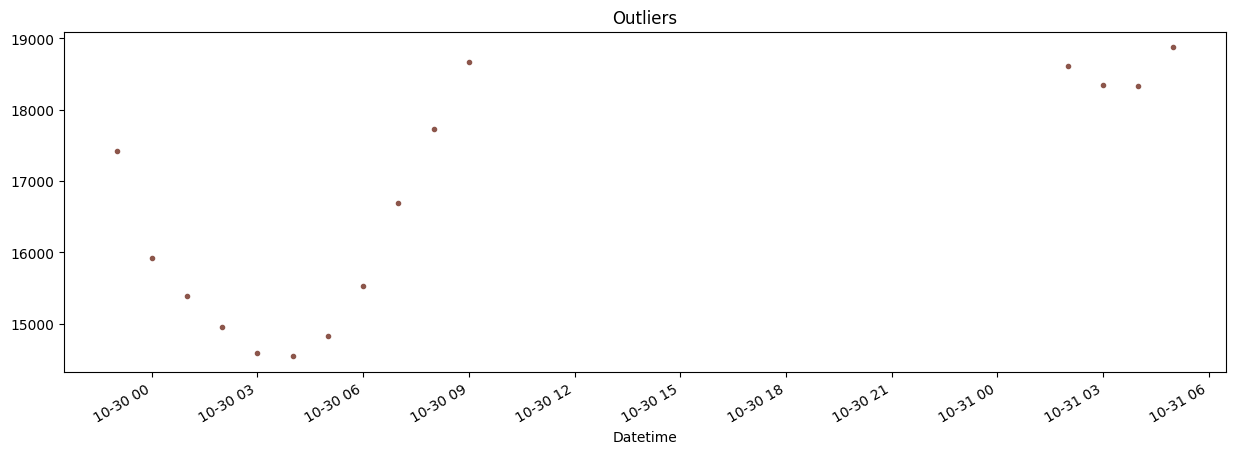

In [ ]:
df.query('PJME_MW < 19_000')['PJME_MW'].plot(style='.',figsize=(15, 5), color=color_pal[5],title='Outliers');

Se genera un array de números aleatorios uniformemente distribuidos entre 19000 y 20000.

In [ ]:
condicion = df['PJME_MW'] < 19000
df.loc[condicion, 'PJME_MW'] = np.random.uniform(19000, 20000, condicion.sum())

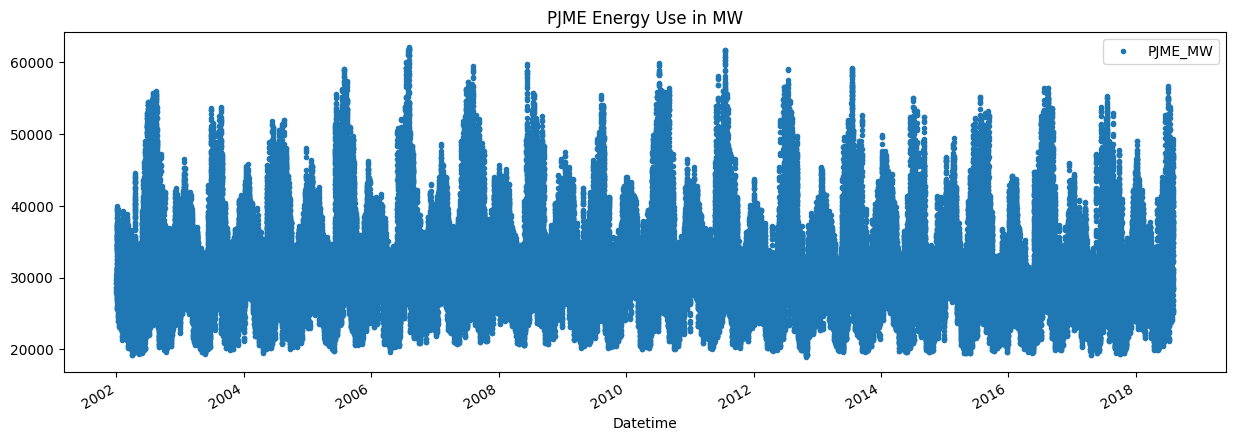

In [ ]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

**Separación del dataset en train, test**

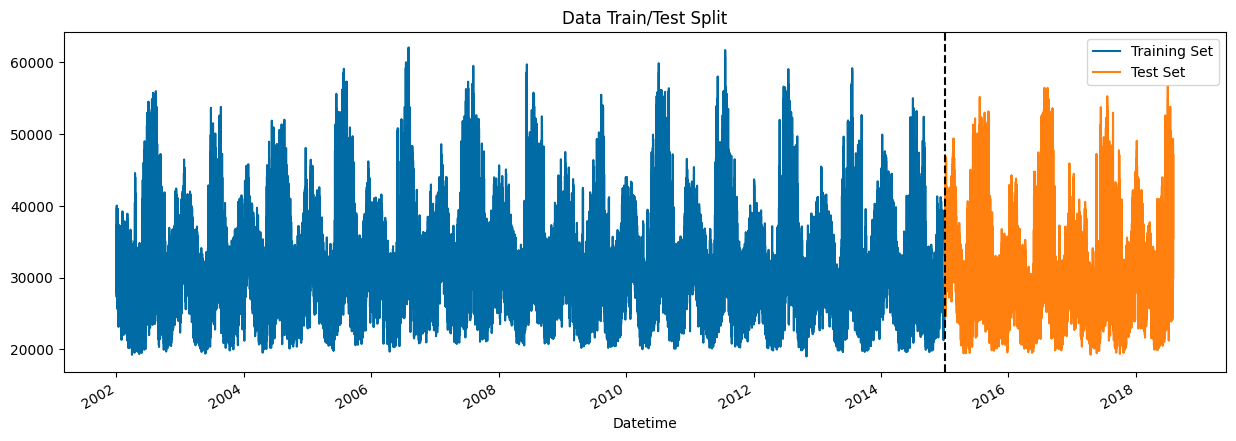

In [ ]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

**Cross Validation para Series de Tiempo**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

La siguiente línea de código crea un objeto de tipo TimeSeriesSplit que se utiliza para dividir una serie temporal en conjuntos de entrenamiento y prueba para su validación cruzada.

n_splits=5: Indica que se dividirá la serie temporal en 5 conjuntos diferentes  

Gap: se asegura que el conjunto de prueba refleje mejor una situación en la que solo se tiene información hasta un cierto punto en el tiempo, y el modelo debe hacer predicciones futuras basadas en ese conocimiento limitado.

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24) #se están dejando 24 hrs como brecha entre el conjunto de entrenamiento y el conjunto de prueba. (mayor representatividad)
df = df.sort_index()

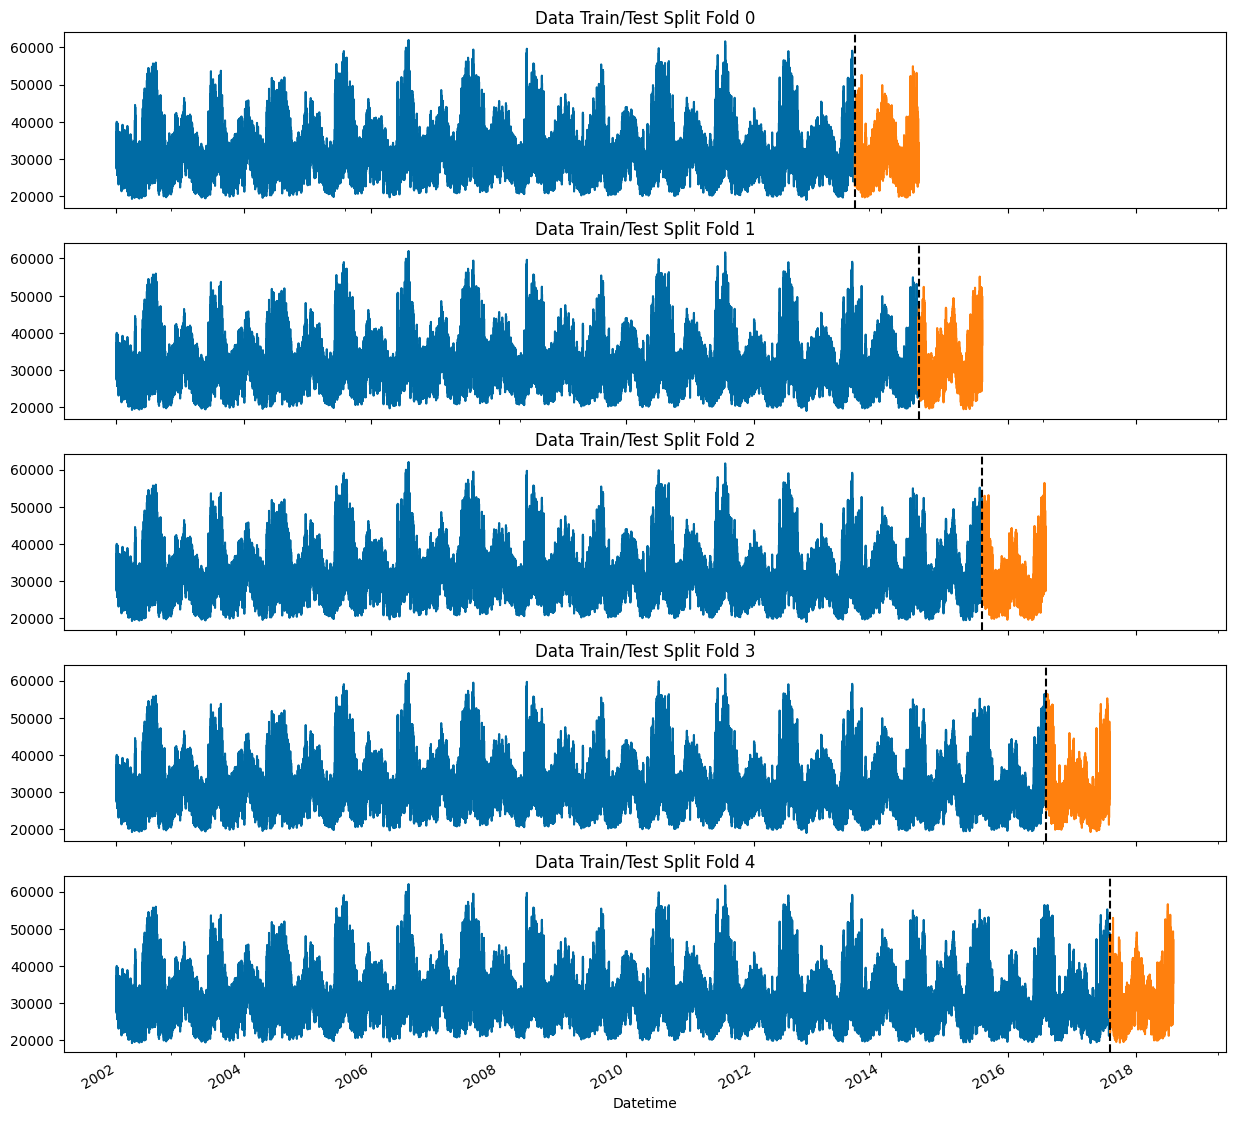

In [ ]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    val = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    val['PJME_MW'].plot(ax=axs[fold],label='Val Set')
    axs[fold].axvline(val.index.min(), color='black', ls='--')
    fold += 1
plt.show()

Visualizamos la estructura de tss

In [ ]:
tss

TimeSeriesSplit(gap=24, max_train_size=None, n_splits=5, test_size=8760)

In [ ]:
for i, (train_index, test_index) in enumerate(tss.split(df)):
     print(f"Fold {i}:")
     print(f"  Train: index={train_index}")
     print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[     0      1      2 ... 101539 101540 101541]
  Test:  index=[101566 101567 101568 ... 110323 110324 110325]
Fold 1:
  Train: index=[     0      1      2 ... 110299 110300 110301]
  Test:  index=[110326 110327 110328 ... 119083 119084 119085]
Fold 2:
  Train: index=[     0      1      2 ... 119059 119060 119061]
  Test:  index=[119086 119087 119088 ... 127843 127844 127845]
Fold 3:
  Train: index=[     0      1      2 ... 127819 127820 127821]
  Test:  index=[127846 127847 127848 ... 136603 136604 136605]
Fold 4:
  Train: index=[     0      1      2 ... 136579 136580 136581]
  Test:  index=[136606 136607 136608 ... 145363 145364 145365]


**Feature Engineering**

In [ ]:
def create_features(df):
    """
    Creamos features basadas en el índice tiempo.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

In [ ]:
df = create_features(df)

Agregamos rezagos de la variable target (para agregar información histórica como features):

In [ ]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [ ]:
df = add_lags(df)

In [ ]:
df.head(3)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,NaN,NaN,NaN


Verificaciones:

In [ ]:
# List of specific dates to filter
specific_dates = ['2002-12-30 23:00:00' ,'2003-12-30 23:00:00','2004-12-31 01:00:00','2005-01-01 00:00:00','2005-12-31 00:00:00']

# Convert the list of specific dates to a DatetimeIndex
specific_dates_index = pd.to_datetime(specific_dates)

# Filter the DataFrame using the isin method
filtered_df = df[df.index.isin(specific_dates_index)]

filtered_df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,,,
2002-12-30 23:00:00,31619.0,23,0,4,12,2002,364,30,1,NaN,NaN,NaN
2003-12-30 23:00:00,32228.0,23,1,4,12,2003,364,30,1,28483.0,31857.0,NaN
2004-12-31 01:00:00,27160.0,1,4,4,12,2004,366,31,53,25421.0,28141.0,29338.0
2005-01-01 00:00:00,27384.0,0,5,1,1,2005,1,1,53,27539.0,30533.0,30924.0
2005-12-31 00:00:00,30900.0,0,5,4,12,2005,365,31,52,27384.0,27539.0,30533.0


In [ ]:
target_index = '2004-12-31 00:00:00'
lag_value1 = df.loc[target_index, 'lag1']
lag_value2 = df.loc[target_index, 'lag2']
lag_value3 = df.loc[target_index, 'lag3']

print(f"El valor correspondiente al índice {target_index} y el lag de 364 días es: {lag_value1}")
print(f"El valor correspondiente al índice {target_index} y el lag de 728 días es: {lag_value2}")
print(f"El valor correspondiente al índice {target_index} y el lag de 1092 días es: {lag_value3}")

El valor correspondiente al índice 2004-12-31 00:00:00 y el lag de 364 días es: 27446.0
El valor correspondiente al índice 2004-12-31 00:00:00 y el lag de 728 días es: 30228.0
El valor correspondiente al índice 2004-12-31 00:00:00 y el lag de 1092 días es: 31038.0


In [ ]:
# Para obtener el índice de fila correspondiente al índice '2002-12-31 01:00:00' y el lag de 364 días
target_index = '2004-12-31 00:00:00'
lag_days1 = 364
lag_days2 = 728
lag_days3 = 1092

# Convierte el índice objetivo a un objeto Timestamp
target_index_dt = pd.to_datetime(target_index)

# Calcula el índice de fila utilizando iloc y la diferencia en días
target_row_index1 = df.index.get_loc(target_index_dt - pd.Timedelta(days=lag_days1))
target_row_index2 = df.index.get_loc(target_index_dt - pd.Timedelta(days=lag_days2))
target_row_index3 = df.index.get_loc(target_index_dt - pd.Timedelta(days=lag_days3))

print(f"El índice de fila correspondiente al índice {target_index} y el lag de {lag_days1} días es: {target_row_index1}")
print(f"El índice de fila correspondiente al índice {target_index} y el lag de {lag_days2} días es: {target_row_index2}")
print(f"El índice de fila correspondiente al índice {target_index} y el lag de {lag_days3} días es: {target_row_index3}")

El índice de fila correspondiente al índice 2004-12-31 00:00:00 y el lag de 364 días es: 17539
El índice de fila correspondiente al índice 2004-12-31 00:00:00 y el lag de 728 días es: 8805
El índice de fila correspondiente al índice 2004-12-31 00:00:00 y el lag de 1092 días es: 71


In [ ]:
# Lista de índices iloc a filtrar
indices_iloc = [17539,8805,71]

# Filtrar el DataFrame original solo en la columna 'PJME_MW' para los índices iloc
filtered_column = df['PJME_MW'].iloc[indices_iloc]

# Mostrar el resultado
filtered_column

,PJME_MW
Datetime,
2004-01-02,27446.0
2003-01-03,30228.0
2002-01-04,31038.0


Simplemente corroboramos con los índices el dataframe original que los lags elaborados correspondan respectivamente a 1, 2 y 3 años.

**Entrenamiento**

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

Esto permite evaluar el desempeño del modelo en diferentes segmentos temporales del dataset.

In [ ]:
fold = 0
preds = [] #Almacena las predicciones de cada partición
scores = [] #Guarda el RMSE de cada partición
for train_idx, val_idx in tss.split(df): #Iterar sobre las particiones
    train = df.iloc[train_idx]
    val = df.iloc[val_idx]

    #train = create_features(train)
    #val = create_features(val)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1','lag2','lag3'] #Extraer características y target
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_val = val[FEATURES]
    y_val = val[TARGET]

    reg = xgb.XGBRegressor(booster='gbtree', #utilizar modelado basado en árboles
                           n_estimators=1000, #n_estimators – Número de árboles que llevan a cabo el boosting. También se entiende como el número de iteraciones de boosting.
                           objective='reg:linear', #Aquí es donde se indica si queremos hacer regresión
                           max_depth=3, #Máxima profundidad de un arbol.
                           learning_rate=0.01,
                           eval_metric=['rmse', 'mae'] )
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=100)

    y_pred = reg.predict(X_val)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_val, y_pred))
    scores.append(score)

[0]	validation_0-rmse:6458.57134	validation_0-mae:4965.28269	validation_1-rmse:6142.83531	validation_1-mae:4949.45041


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:59:26] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:4369.17665	validation_0-mae:3286.92681	validation_1-rmse:4103.37232	validation_1-mae:3336.70752
[200]	validation_0-rmse:3812.81774	validation_0-mae:2843.24999	validation_1-rmse:3765.04115	validation_1-mae:2980.59793
[300]	validation_0-rmse:3537.32867	validation_0-mae:2627.78443	validation_1-rmse:3718.48650	validation_1-mae:2864.56484
[400]	validation_0-rmse:3386.64712	validation_0-mae:2503.38384	validation_1-rmse:3748.41707	validation_1-mae:2844.01898
[500]	validation_0-rmse:3310.82841	validation_0-mae:2442.18372	validation_1-rmse:3769.91318	validation_1-mae:2839.79313
[600]	validation_0-rmse:3261.01364	validation_0-mae:2403.96432	validation_1-rmse:3789.13916	validation_1-mae:2844.32372
[700]	validation_0-rmse:3221.65111	validation_0-mae:2375.92531	validation_1-rmse:3795.89591	validation_1-mae:2844.69763
[800]	validation_0-rmse:3188.42325	validation_0-mae:2350.42897	validation_1-rmse:3798.95140	validation_1-mae:2841.94928
[900]	validation_0-rmse:3158.91872	valid

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:59:37] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:4372.03931	validation_0-mae:3297.57802	validation_1-rmse:4158.98912	validation_1-mae:3341.19117
[200]	validation_0-rmse:3834.96871	validation_0-mae:2861.96055	validation_1-rmse:3698.51155	validation_1-mae:2875.90642
[300]	validation_0-rmse:3577.17267	validation_0-mae:2658.87379	validation_1-rmse:3557.02097	validation_1-mae:2709.42741
[400]	validation_0-rmse:3430.48545	validation_0-mae:2537.93795	validation_1-rmse:3519.50228	validation_1-mae:2646.13558
[500]	validation_0-rmse:3347.38863	validation_0-mae:2471.95369	validation_1-rmse:3498.65588	validation_1-mae:2600.70072
[600]	validation_0-rmse:3297.29974	validation_0-mae:2435.10122	validation_1-rmse:3477.02600	validation_1-mae:2565.13675
[700]	validation_0-rmse:3257.39947	validation_0-mae:2404.63236	validation_1-rmse:3463.14975	validation_1-mae:2543.08305
[800]	validation_0-rmse:3222.33383	validation_0-mae:2378.07228	validation_1-rmse:3439.69885	validation_1-mae:2507.02990
[900]	validation_0-rmse:3192.06101	valid

...

[100]	validation_0-rmse:4367.65009	validation_0-mae:3302.86053	validation_1-rmse:4471.82440	validation_1-mae:3684.42508
[200]	validation_0-rmse:3832.96381	validation_0-mae:2862.92367	validation_1-rmse:3914.38991	validation_1-mae:3181.74006
[300]	validation_0-rmse:3588.04919	validation_0-mae:2666.55371	validation_1-rmse:3703.63306	validation_1-mae:2973.48920
[400]	validation_0-rmse:3447.08854	validation_0-mae:2549.92903	validation_1-rmse:3630.96735	validation_1-mae:2887.08982
[500]	validation_0-rmse:3371.34439	validation_0-mae:2488.89582	validation_1-rmse:3611.75217	validation_1-mae:2863.13060
[600]	validation_0-rmse:3318.44591	validation_0-mae:2449.87439	validation_1-rmse:3615.41669	validation_1-mae:2862.52984
[700]	validation_0-rmse:3276.97986	validation_0-mae:2418.88022	validation_1-rmse:3641.24165	validation_1-mae:2884.86536
[800]	validation_0-rmse:3242.42020	validation_0-mae:2392.01614	validation_1-rmse:3672.74536	validation_1-mae:2921.52445
[900]	validation_0-rmse:3216.65890	valid

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:59:59] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:4367.08068	validation_0-mae:3308.21270	validation_1-rmse:4642.52946	validation_1-mae:3665.33934
[200]	validation_0-rmse:3829.62954	validation_0-mae:2864.33309	validation_1-rmse:4274.37636	validation_1-mae:3288.20217
[300]	validation_0-rmse:3591.26958	validation_0-mae:2670.36873	validation_1-rmse:4178.03247	validation_1-mae:3150.82316
[400]	validation_0-rmse:3451.80206	validation_0-mae:2557.32290	validation_1-rmse:4133.76465	validation_1-mae:3063.65387
[500]	validation_0-rmse:3377.60988	validation_0-mae:2498.07115	validation_1-rmse:4099.67505	validation_1-mae:2988.18790
[600]	validation_0-rmse:3324.19602	validation_0-mae:2458.67650	validation_1-rmse:4100.63774	validation_1-mae:2964.44127
[700]	validation_0-rmse:3282.68882	validation_0-mae:2426.06006	validation_1-rmse:4085.84956	validation_1-mae:2940.95219
[800]	validation_0-rmse:3251.59145	validation_0-mae:2402.72824	validation_1-rmse:4087.20764	validation_1-mae:2934.72878
[900]	validation_0-rmse:3224.90699	valid

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:00:11] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:4388.90080	validation_0-mae:3328.98673	validation_1-rmse:4184.46541	validation_1-mae:3268.48107
[200]	validation_0-rmse:3861.98582	validation_0-mae:2892.83523	validation_1-rmse:3875.71828	validation_1-mae:2930.33047
[300]	validation_0-rmse:3631.05663	validation_0-mae:2702.72871	validation_1-rmse:3881.46666	validation_1-mae:2884.20491
[400]	validation_0-rmse:3494.51733	validation_0-mae:2589.86818	validation_1-rmse:3951.85541	validation_1-mae:2904.05461
[500]	validation_0-rmse:3422.87873	validation_0-mae:2528.52363	validation_1-rmse:4015.83948	validation_1-mae:2938.34327
[600]	validation_0-rmse:3373.97876	validation_0-mae:2490.71183	validation_1-rmse:4046.15605	validation_1-mae:2962.53311
[700]	validation_0-rmse:3337.82391	validation_0-mae:2463.04547	validation_1-rmse:4048.51733	validation_1-mae:2964.81073
[800]	validation_0-rmse:3306.45795	validation_0-mae:2438.03339	validation_1-rmse:4046.85522	validation_1-mae:2963.89760
[900]	validation_0-rmse:3277.05358	valid

In [ ]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3799.9878
Fold scores:[np.float64(3781.2575026384934), np.float64(3422.31278754437), np.float64(3723.011961817741), np.float64(4053.336439228018), np.float64(4020.020113641144)]


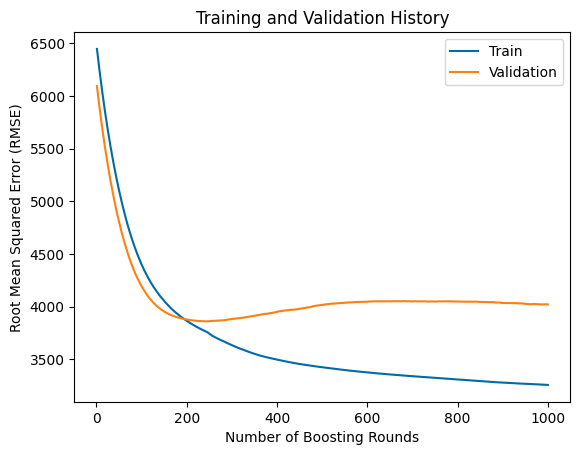

In [ ]:
# Plot the training and validation history
results = reg.evals_result()
train_error = results['validation_0']['rmse']
val_error = results['validation_1']['rmse']

epoch = range(1, len(train_error) + 1)

plt.plot(epoch, train_error, label='Train')
plt.plot(epoch, val_error, label='Validation')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Training and Validation History')
plt.legend()
plt.show()

A continuación ploteamos la importancia de las características del modelo XGBRegressor entrenado

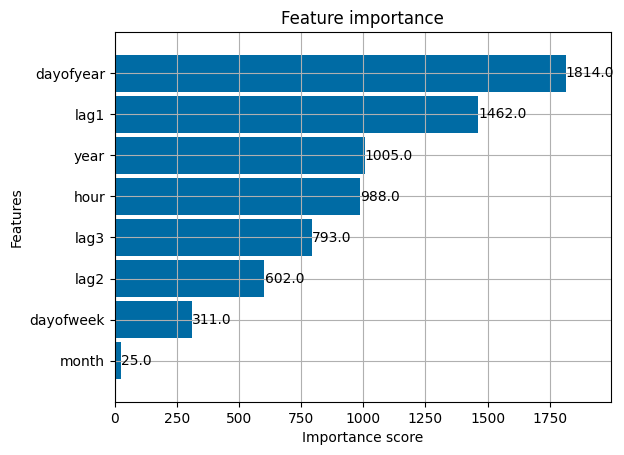

In [ ]:
_ = plot_importance(reg, height=0.9)

**Pronostico sobre los datos de Test**

In [ ]:
y_pred = reg.predict(X_val)

In [ ]:
y_pred

array([29258.352, 28259.445, 27448.73 , ..., 39382.215, 36764.684,
       31688.488], dtype=float32)

Adicionamos la predicción al set de Validación

In [ ]:
val['prediction'] = reg.predict(X_val)

/tmp/ipython-input-1799221841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['prediction'] = reg.predict(X_val)


In [ ]:
val['prediction']

,prediction
Datetime,
2017-08-03 01:00:00,29258.351562
2017-08-03 02:00:00,28259.445312
2017-08-03 03:00:00,27448.730469
2017-08-03 04:00:00,26771.912109
2017-08-03 05:00:00,26786.691406
...,...
2018-08-02 20:00:00,42544.144531
2018-08-02 21:00:00,41699.835938
2018-08-02 22:00:00,39382.214844


In [ ]:
val

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,prediction
Datetime,,,,,,,,,,,,,
2017-08-03 01:00:00,29189.0,1,3,3,8,2017,215,3,31,28809.0,29952.0,28465.0,29258.351562
2017-08-03 02:00:00,27584.0,2,3,3,8,2017,215,3,31,27039.0,27934.0,26712.0,28259.445312
2017-08-03 03:00:00,26544.0,3,3,3,8,2017,215,3,31,25881.0,26659.0,25547.0,27448.730469
2017-08-03 04:00:00,26012.0,4,3,3,8,2017,215,3,31,25300.0,25846.0,24825.0,26771.912109
2017-08-03 05:00:00,26187.0,5,3,3,8,2017,215,3,31,25412.0,25898.0,24927.0,26786.691406
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,2,31,42256.0,41485.0,38804.0,42544.144531
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,2,31,41210.0,40249.0,38748.0,41699.835938
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,2,31,39525.0,38698.0,37330.0,39382.214844


**Visualización de la predicción y los datos originales:**

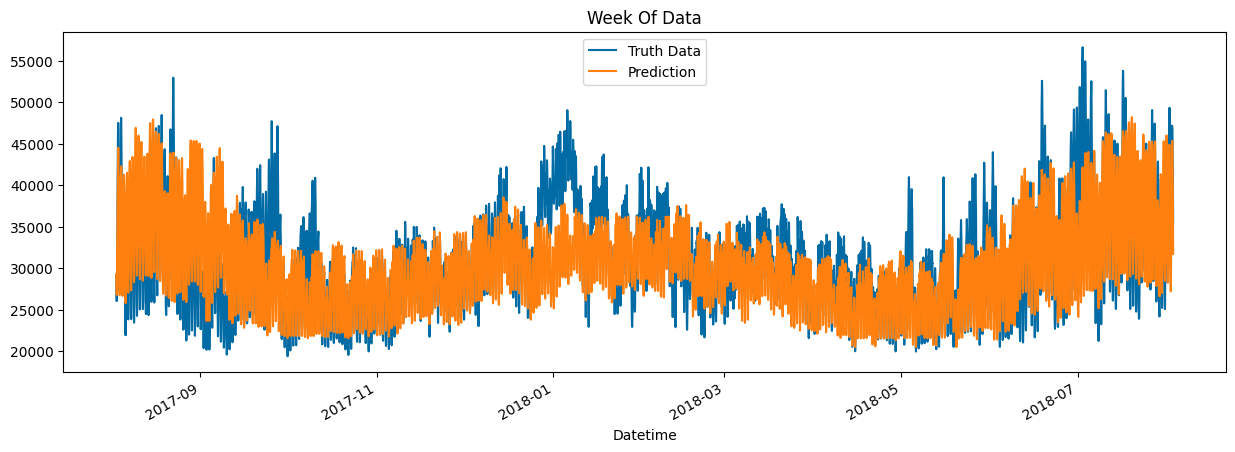

In [ ]:
ax = val.loc[(val.index >= '2017-08-03')]['PJME_MW'].plot(figsize=(15, 5), title='Week Of Data')
val.loc[(val.index >= '2017-08-03')]['prediction'].plot()
plt.legend(['Truth Data','Prediction'])
plt.show()

**Métricas de performance:**

In [ ]:
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Calculate error metrics using the filtered data
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
score = np.sqrt(mean_squared_error(y_val, y_pred))

In [ ]:
# Print the error metrics
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print(f'RMSE Score on Test set: {score:0.2f}')

Mean Squared Error (MSE): 16160561.714079354
Mean Absolute Error (MAE): 2950.1612494203055
RMSE Score on Test set: 4020.02


# Optimización con Opptuna
A continuación se genera un script en Python con otro manejo de outliers, optimización de código e implementación de Optuna para la optimización bayesiana de hiperparámetros para el modelo XGBoost, utilizando validación cruzada con TimeSeriesSplit.

https://optuna.org/

## Carga y procesamiento inicial de datos

Mantener la carga de datos, conversión a datetime y configuración del índice.


**Carga de datos**:

In [ ]:
import pandas as pd

URL = 'https://raw.githubusercontent.com/braiandrago/AST/main/consumo_2.csv'
df = pd.read_csv(URL)
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('Datetime')
df.sort_index(inplace=True)

## Manejo de outliers

Mejorar el manejo de outliers para que sea más robusto.Realizamos la detección y corrección de valores atípicos (outliers) sobre la columna 'PJME_MW' de un DataFrame llamado df, utilizando el método del rango intercuartílico (IQR)


Descriptive statistics after outlier handling:


,PJME_MW
count,145366.000000
mean,31611.711143
std,5720.326470
min,15526.000000
25%,27574.000000
50%,31421.000000
75%,35126.000000
max,47765.000000


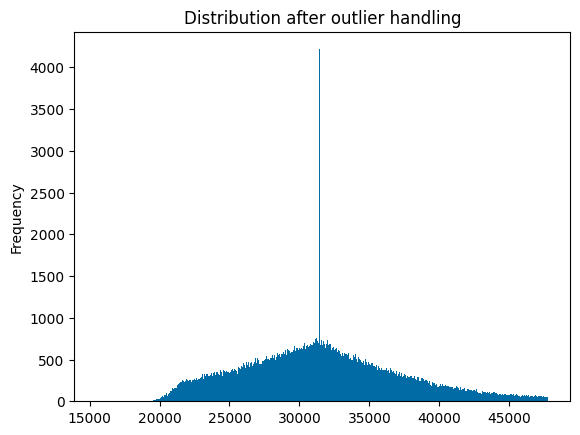

In [ ]:
Q1 = df['PJME_MW'].quantile(0.25)
Q3 = df['PJME_MW'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['PJME_MW'] < lower_bound) | (df['PJME_MW'] > upper_bound)

median_pjme = df['PJME_MW'].median()
df.loc[outlier_mask, 'PJME_MW'] = median_pjme

print("Descriptive statistics after outlier handling:")
display(df['PJME_MW'].describe())

df['PJME_MW'].plot(kind='hist', bins=500, title='Distribution after outlier handling');

## Ingeniería de características

In [ ]:
def create_features(df):
    """
    Create time series features based on index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int) # Convert to int
    return df

## Adición de lags

In [ ]:
def add_lags(df):
    """
    Add lag features to the DataFrame.
    """
    df_copy = df.copy()
    lag_periods = [364 * 24, 728 * 24, 1092 * 24] # Lags of 1, 2, and 3 years in hours

    for lag_period in lag_periods:
        df_copy[f'lag_{lag_period}'] = df_copy['PJME_MW'].shift(lag_period)

    return df_copy

In [ ]:
df = add_lags(df)
display(df.head())

,PJME_MW,lag_8736,lag_17472,lag_26208
Datetime,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,NaN,NaN,NaN


## División de datos y validación cruzada

Mantener la división de datos con `TimeSeriesSplit`.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

for i, (train_index, test_index) in enumerate(tss.split(df)):
     print(f"Fold {i}:")
     print(f"  Train: index={train_index}")
     print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[     0      1      2 ... 101539 101540 101541]
  Test:  index=[101566 101567 101568 ... 110323 110324 110325]
Fold 1:
  Train: index=[     0      1      2 ... 110299 110300 110301]
  Test:  index=[110326 110327 110328 ... 119083 119084 119085]
Fold 2:
  Train: index=[     0      1      2 ... 119059 119060 119061]
  Test:  index=[119086 119087 119088 ... 127843 127844 127845]
Fold 3:
  Train: index=[     0      1      2 ... 127819 127820 127821]
  Test:  index=[127846 127847 127848 ... 136603 136604 136605]
Fold 4:
  Train: index=[     0      1      2 ... 136579 136580 136581]
  Test:  index=[136606 136607 136608 ... 145363 145364 145365]


## Implementación de optuna

Implementar Optuna para la optimización bayesiana de hiperparámetros para un modelo XGBoost, utilizando validación cruzada con TimeSeriesSplit.


In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 16.7 MB/s eta 0:00:00


In [ ]:
import optuna

Definimos la función objetivo de OPTUNA, que performará con timeseriessplit, entrenara el modelo con los hiperparámetros sugeridos y devolverá el average de RMSE.



[I 2025-06-24 00:27:58,617] A new study created in memory with name: no-name-2719fb01-2bf2-487a-925d-c9380e311506
[I 2025-06-24 00:28:39,015] Trial 0 finished with value: 3825.716672548648 and parameters: {'n_estimators': 423, 'max_depth': 8, 'learning_rate': 0.05604573093576225, 'subsample': 0.9050284488501316, 'colsample_bytree': 0.9213156643239685, 'reg_alpha': 2.5184737100604987e-06, 'reg_lambda': 1.582226072246819e-07}. Best is trial 0 with value: 3825.716672548648.
[I 2025-06-24 00:28:44,397] Trial 1 finished with value: 3619.524754324956 and parameters: {'n_estimators': 105, 'max_depth': 4, 'learning_rate': 0.056250169587901716, 'subsample': 0.7662374030637328, 'colsample_bytree': 0.762085027533136, 'reg_alpha': 0.11217836423739, 'reg_lambda': 7.969576382389275e-05}. Best is trial 1 with value: 3619.524754324956.
[I 2025-06-24 00:29:00,417] Trial 2 finished with value: 3595.5747011021604 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.08066650173637158, 

Best hyperparameters:  {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.08066650173637158, 'subsample': 0.9466120805432646, 'colsample_bytree': 0.967706993841483, 'reg_alpha': 0.0034509153217537514, 'reg_lambda': 1.725711801075082e-08}
Best RMSE:  3595.5747011021604


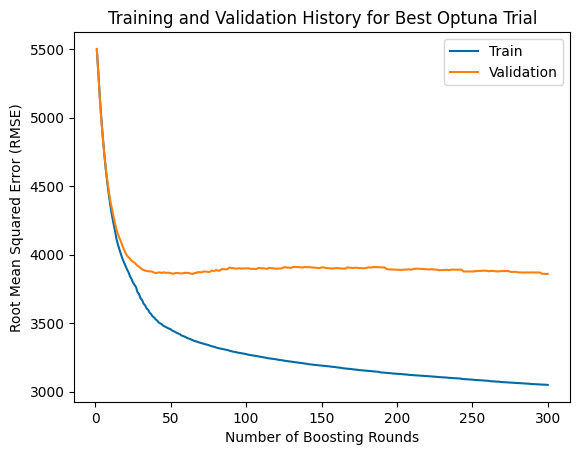

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt

def objective(trial):
    """Objective function for Optuna."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_jobs': -1
    }

    tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
    rmse_scores = []

    df_processed = create_features(df.copy()) # Apply feature engineering
    df_processed = add_lags(df_processed) # Apply lag features
    df_processed.dropna(inplace=True) # Drop rows with NaN values from lags


    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag_8736','lag_17472','lag_26208'] # Update feature names
    TARGET = 'PJME_MW'

    X = df_processed[FEATURES]
    y = df_processed[TARGET]

    models = []  # Store trained models to get eval_results later

    for train_idx, val_idx in tss.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        reg = xgb.XGBRegressor(**params)

        eval_set = [(X_train, y_train), (X_val, y_val)]

        reg.fit(X_train, y_train,
                eval_set=eval_set,
                verbose=False)

        models.append(reg)  # Store the trained model

        y_pred = reg.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_scores.append(rmse)

    # Store the evaluation results for the last fold of this trial
    trial.set_user_attr('eval_results', models[-1].evals_result())

    return np.mean(rmse_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

print("Best hyperparameters: ", study.best_params)
print("Best RMSE: ", study.best_value)

# Plot the training and validation history for the best trial
best_trial = study.best_trial
results = best_trial.user_attrs['eval_results']
train_error = results['validation_0']['rmse']
val_error = results['validation_1']['rmse']

epoch = range(1, len(train_error) + 1)

plt.plot(epoch, train_error, label='Train')
plt.plot(epoch, val_error, label='Validation')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Training and Validation History for Best Optuna Trial')
plt.legend()
plt.show()

## Entrenamiento del modelo final

Entrenar el modelo XGBoost con los mejores hiperparámetros encontrados por Optuna en el conjunto de datos completo de entrenamiento.


In [ ]:
# Define features and target
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
            'lag_8736','lag_17472','lag_26208']
TARGET = 'PJME_MW'

# Apply feature engineering and lag features to the full DataFrame
df_processed = create_features(df.copy())
df_processed = add_lags(df_processed)
df_processed.dropna(inplace=True) # Drop rows with NaN values from lags

# Split data into training and testing sets using the original split point
train_cutoff = '01-01-2015'
X_train_final = df_processed.loc[df_processed.index < train_cutoff, FEATURES]
y_train_final = df_processed.loc[df_processed.index < train_cutoff, TARGET]
X_test_final = df_processed.loc[df_processed.index >= train_cutoff, FEATURES]
y_test_final = df_processed.loc[df_processed.index >= train_cutoff, TARGET]

# Initialize XGBoost model with best hyperparameters from Optuna
best_params = study.best_params
final_reg = xgb.XGBRegressor(**best_params,
                             objective='reg:squarederror',
                             eval_metric='rmse',
                             random_state=42,
                             n_jobs=-1)

# Train the final model on the full training set
final_reg.fit(X_train_final, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.967706993841483, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.08066650173637158,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## Evaluación del modelo final

Evaluar el modelo final en el conjunto de datos de prueba.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions on the test set
y_pred_final = final_reg.predict(X_test_final)

# Calculate RMSE on the test set
rmse_final = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

# Calculate MAE on the test set
mae_final = mean_absolute_error(y_test_final, y_pred_final)

# Print the evaluation metrics
print(f"Final Model RMSE on Test Set: {rmse_final:0.2f}")
print(f"Final Model MAE on Test Set: {mae_final:0.2f}")

Final Model RMSE on Test Set: 3816.01
Final Model MAE on Test Set: 2965.30


## Visualización de resultados

Visualizar las predicciones y la importancia de las características del modelo final.


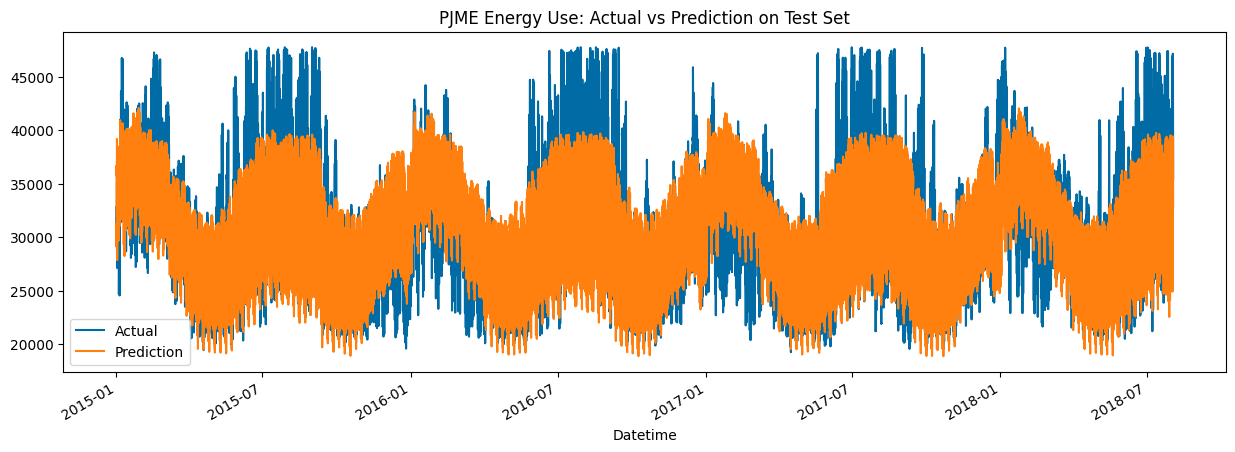

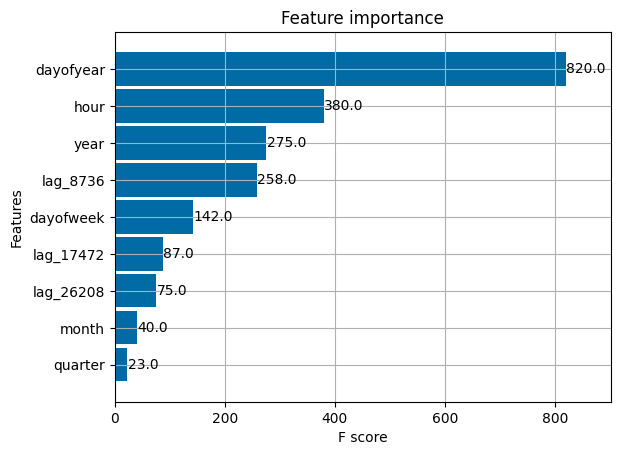

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import plot_importance

# 1. Create a new DataFrame called test_results from the X_test_final DataFrame
test_results = X_test_final.copy()
test_results['Actual'] = y_test_final
test_results['Prediction'] = y_pred_final

# 2. Plot the 'Actual' and 'Prediction' columns of the test_results DataFrame
plt.figure(figsize=(15, 5))
test_results['Actual'].plot(label='Actual')
test_results['Prediction'].plot(label='Prediction')
plt.title('PJME Energy Use: Actual vs Prediction on Test Set')

# 3. Add a legend to the plot to distinguish between the 'Actual' and 'Prediction' lines.
plt.legend()

# 4. Display the plot.
plt.show()

# 5. Generate a plot showing the importance of the features in the final_reg model
plot_importance(final_reg, height=0.9)

# 6. Display the feature importance plot.
plt.show()

Para seguir mejorando...  
Probar más Trials.  
Analizar el feature importance plot para entender cuales features contribuyen más al modelo (tienen mayor poder de predicción).   
Se pueden refinar estas variables / buscar nuevas.